# Construction du moteur de similarité sémantique

Cette étape consiste à comparer un profil utilisateur avec le référentiel de compétences.

Le moteur repose sur :

- Sentence-BERT multilingue
- Similarité cosinus
- Scoring par blocs de compétences

Objectifs :

- Identifier les compétences les plus proches du profil utilisateur
- Calculer un score global de couverture
- Identifier les domaines de compétence dominants

In [1]:
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

In [2]:
competencies_df = pd.read_csv(
    "../data/gold/competencies.csv"
)

competency_embeddings = np.load(
    "../data/gold/competency_embeddings.npy"
)

In [3]:
model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2",
    device="cpu"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [4]:
user_profile = """

J’ai développé des applications en Python.

J’ai travaillé sur des pipelines Docker.

J’ai déployé des services cloud avec AWS.

J’ai entraîné plusieurs modèles de machine learning.

"""

In [5]:
user_embedding = model.encode(
    [user_profile]
)

In [6]:
similarities = cosine_similarity(
    user_embedding,
    competency_embeddings
)[0]

In [7]:
results_df = competencies_df.copy()

results_df["similarity_score"] = similarities

In [ ]:
results_df = results_df.sort_values(
    by="similarity_score",
    ascending=False
)

results_df[
    ["competency",
     "block",
     "similarity_score"]
]

,competency,block,similarity_score
12,Python,Programming,0.632241
0,AWS,Cloud & DevOps,0.544859
9,Machine Learning,AI / Machine Learning,0.522776
17,TensorFlow,AI / Machine Learning,0.511118
2,CI/CD,Cloud & DevOps,0.474234
13,REST APIs,Backend Engineering,0.464196
3,Docker,Cloud & DevOps,0.451593
5,Go,Programming,0.446706
15,Ruby,Programming,0.432794
11,Node.js,Programming,0.423021


On garde seulement scores > 0.45

In [9]:
relevant_skills = results_df[
    results_df["similarity_score"] > 0.45
]

relevant_skills

,competency_id,competency,block,semantic_description,similarity_score
12,C013,Python,Programming,"Capacité à développer des logiciels, scripts d...",0.632241
0,C001,AWS,Cloud & DevOps,Expérience dans le déploiement d'infrastructur...,0.544859
9,C010,Machine Learning,AI / Machine Learning,"Capacité à entraîner, évaluer et déployer des ...",0.522776
17,C018,TensorFlow,AI / Machine Learning,Capacité à construire et entraîner des modèles...,0.511118
2,C003,CI/CD,Cloud & DevOps,Capacité à automatiser les processus de compil...,0.474234
13,C014,REST APIs,Backend Engineering,"Capacité à concevoir, consommer et documenter ...",0.464196
3,C004,Docker,Cloud & DevOps,Capacité à conteneuriser des applications et à...,0.451593


Pourquoi ?

Éviter bruit.

In [10]:
block_scores = relevant_skills.groupby(
    "block"
)["similarity_score"].mean().reset_index()

In [11]:
block_scores = block_scores.sort_values(
    by="similarity_score",
    ascending=False
)

block_scores

,block,similarity_score
3,Programming,0.632241
0,AI / Machine Learning,0.516947
2,Cloud & DevOps,0.490229
1,Backend Engineering,0.464196


In [12]:
global_score = relevant_skills[
    "similarity_score"
].mean()

print(
    "Score global :",
    round(global_score,3)
)

Score global : 0.514


In [13]:
import matplotlib.pyplot as plt

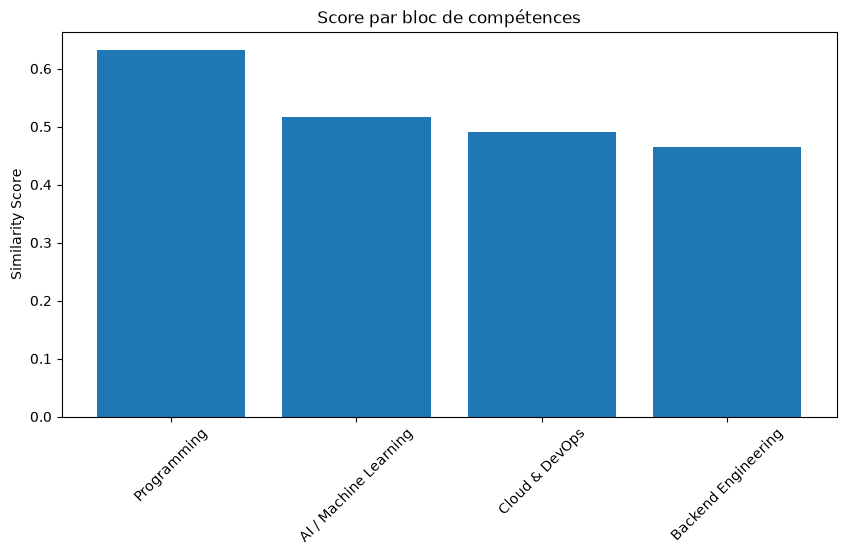

In [14]:
plt.figure(figsize=(10,5))

plt.bar(
    block_scores["block"],
    block_scores["similarity_score"]
)

plt.title(
    "Score par bloc de compétences"
)

plt.xticks(rotation=45)

plt.ylabel("Similarity Score")

plt.show()

In [15]:
relevant_skills.to_csv(
    "../data/gold/user_skill_matches.csv",
    index=False
)